## 1. Предметная область и постановка задачи

Предметная область — медицинская диагностика сердечно-сосудистых заболеваний.

Целевая переменная `num`: 0 — болезни нет, 1–4 — разная степень выраженности.
Преобразую в бинарную: 0 — нет болезни, 1 — есть.

Задача дискриминативная — бинарная классификация.

## 2. Сбор данных

Использую набор **UCI Heart Disease** (папка `heart+disease`).

Данные собраны в 4 клиниках: Cleveland, Hungarian, Long Beach VA, Switzerland. Всего 76 признаков, но обычно используют 14 — беру файлы `processed.*.data`, они уже приведены к единой схеме.

В файле `WARNING` написано, что сырой `cleveland.data` повреждён, поэтому работаю только с processed-версиями.

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

DATA_DIR = Path("heart+disease")

## 3. Загрузка данных

Читаю все 4 файла, имена колонок из `heart-disease.names`.

In [4]:
columns = [
    "age",       # возраст
    "sex",       # пол: 1 - male, 0 - female
    "cp",        # тип боли в груди
    "trestbps",  # давление в покое
    "chol",      # холестерин
    "fbs",       # сахар натощак > 120 mg/dl
    "restecg",   # ЭКГ в покое
    "thalach",   # максимальная ЧСС
    "exang",     # стенокардия при нагрузке
    "oldpeak",   # депрессия ST
    "slope",     # наклон сегмента ST
    "ca",        # число крупных сосудов
    "thal",      # результат thal-теста
    "num",       # целевая переменная
]

source_files = {
    "Cleveland": "processed.cleveland.data",
    "Hungarian": "processed.hungarian.data",
    "Switzerland": "processed.switzerland.data",
    "Long Beach VA": "processed.va.data",
}

frames = []
for source, filename in source_files.items():
    part = pd.read_csv(
        DATA_DIR / filename,
        header=None,
        names=columns,
        na_values="?",
    )
    part["source"] = source
    frames.append(part)

raw = pd.concat(frames, ignore_index=True)
raw.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [5]:
print(f"Размер объединенного набора: {raw.shape[0]} строк, {raw.shape[1]} колонок")
display(raw.groupby("source").size().rename("rows").to_frame())
display(raw.dtypes.to_frame("dtype").T)

Размер объединенного набора: 920 строк, 15 колонок


,rows
source,
Cleveland,303
Hungarian,294
Long Beach VA,200
Switzerland,123


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,object


## 4. Анализ качества данных

Смотрю на пропуски, дубликаты, распределение таргета и подозрительные значения.

,missing_count,missing_percent
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
thalach,55,5.98
exang,55,5.98
chol,30,3.26
restecg,2,0.22


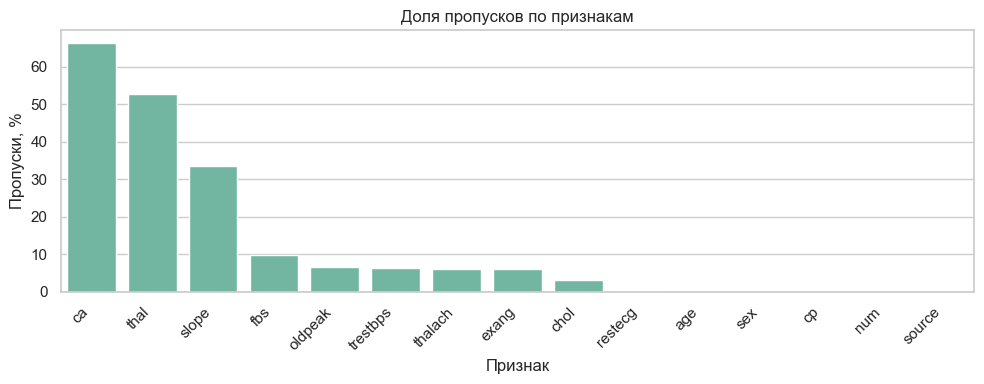

In [6]:
missing = (
    raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: (x["missing_count"] / len(raw) * 100).round(2))
    .sort_values("missing_percent", ascending=False)
)
display(missing)

plt.figure(figsize=(10, 4))
sns.barplot(data=missing.reset_index(), x="index", y="missing_percent")
plt.xticks(rotation=45, ha="right")
plt.title("Доля пропусков по признакам")
plt.xlabel("Признак")
plt.ylabel("Пропуски, %")
plt.tight_layout()
plt.show()

Количество полных дубликатов: 2


,count,percent
num,,
0,411,44.67
1,265,28.80
2,109,11.85
3,107,11.63
4,28,3.04


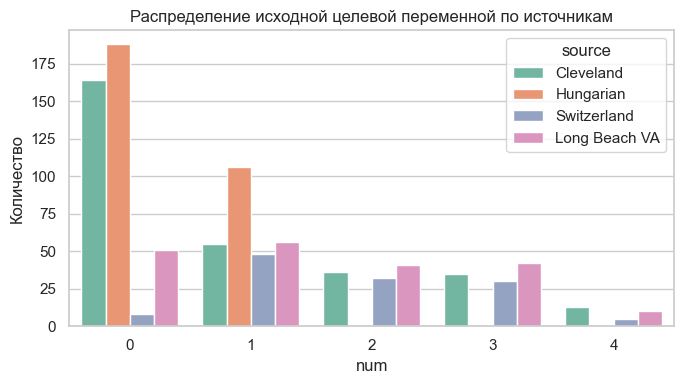

In [7]:
duplicate_count = raw.duplicated().sum()
print(f"Количество полных дубликатов: {duplicate_count}")

target_distribution = raw["num"].value_counts().sort_index().rename_axis("num").to_frame("count")
target_distribution["percent"] = (target_distribution["count"] / len(raw) * 100).round(2)
display(target_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=raw, x="num", hue="source")
plt.title("Распределение исходной целевой переменной по источникам")
plt.xlabel("num")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

In [8]:
numeric_medical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
display(raw[numeric_medical_cols].describe().T)

zero_checks = pd.DataFrame({
    "zero_count": {
        col: int((raw[col] == 0).sum())
        for col in ["trestbps", "chol", "thalach"]
    }
})
display(zero_checks)

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.0,223.0,268.0,603.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2


,zero_count
trestbps,1
chol,172
thalach,0


Выводы:
- `?` при загрузке превратились в `NaN`
- `ca` пропущен у >60% строк — удалю
- `thal` тоже много пропусков, но признак важный — заполню модой
- `chol = 0` физически невозможно (172 случая) — заменяю на NaN
- `trestbps = 0` тоже заменяю
- дубликаты есть — удалю

## 5. Предобработка

Шаги:
1. удалить дубликаты
2. сделать бинарный `target` из `num`
3. заменить нули в `chol` и `trestbps` на NaN
4. удалить `ca` — слишком много пропусков
5. добавить флаги пропусков
6. числовые → медиана + стандартизация
7. категориальные → мода + one-hot encoding

In [9]:
df = raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

df["target"] = (df["num"] > 0).astype(int)

# нули в медицинских показателях — скрытые пропуски
df.loc[df["chol"] == 0, "chol"] = np.nan
df.loc[df["trestbps"] == 0, "trestbps"] = np.nan

initial_features = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

missing_rate_after_zero_fix = df[initial_features].isna().mean().sort_values(ascending=False)
high_missing_cols = missing_rate_after_zero_fix[missing_rate_after_zero_fix > 0.60].index.tolist()
print("Признаки, удаляемые из-за доли пропусков > 60%:", high_missing_cols)

model_features = [col for col in initial_features if col not in high_missing_cols]
cols_with_missing = [col for col in model_features if df[col].isna().any()]

for col in cols_with_missing:
    df[f"{col}_was_missing"] = df[col].isna().astype(int)

indicator_features = [f"{col}_was_missing" for col in cols_with_missing]

numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

X = df[model_features + indicator_features]
y = df["target"]

print(f"После удаления дубликатов: {df.shape[0]} строк")
print(f"Количество признаков до one-hot encoding: {X.shape[1]}")
display(y.value_counts().sort_index().rename({0: "нет болезни", 1: "есть болезнь"}).to_frame("count"))

Признаки, удаляемые из-за доли пропусков > 60%: ['ca']
После удаления дубликатов: 918 строк
Количество признаков до one-hot encoding: 21


,count
target,
нет болезни,410
есть болезнь,508


In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("missing_flag", "passthrough", indicator_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")
X_prepared = preprocessor.fit_transform(X)

prepared = X_prepared.copy()
prepared["target"] = y.to_numpy()
prepared["severity_num"] = df["num"].to_numpy()
prepared["source"] = df["source"].to_numpy()

output_path = Path("heart_disease_preprocessed.csv")
prepared.to_csv(output_path, index=False)

print(f"Итоговый размер матрицы признаков: {X_prepared.shape}")
print(f"Сохранено: {output_path}")
display(prepared.head())

Итоговый размер матрицы признаков: (918, 33)
Сохранено: heart_disease_preprocessed.csv


,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0,trestbps_was_missing,chol_was_missing,fbs_was_missing,restecg_was_missing,thalach_was_missing,exang_was_missing,oldpeak_was_missing,slope_was_missing,thal_was_missing,target,severity_num,source
0,1.006537,0.717747,-0.238774,0.489681,1.365834,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0,0,0,0,0,0,0,0,0,0,Cleveland
1,1.430829,1.555037,0.784507,-1.180980,0.609600,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1,2,Cleveland
2,1.430829,-0.677737,-0.316003,-0.345649,1.649422,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,0,1,1,Cleveland
3,-1.751359,-0.119543,0.089448,1.961454,2.500185,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,Cleveland
4,-1.327067,-0.119543,-0.798682,1.364789,0.515071,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,Cleveland


## 6. Быстрая проверка на модели

Проверяю, что данные нормально передаются в модель без ошибок.

              precision    recall  f1-score   support

 нет болезни       0.86      0.83      0.84        82
есть болезнь       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



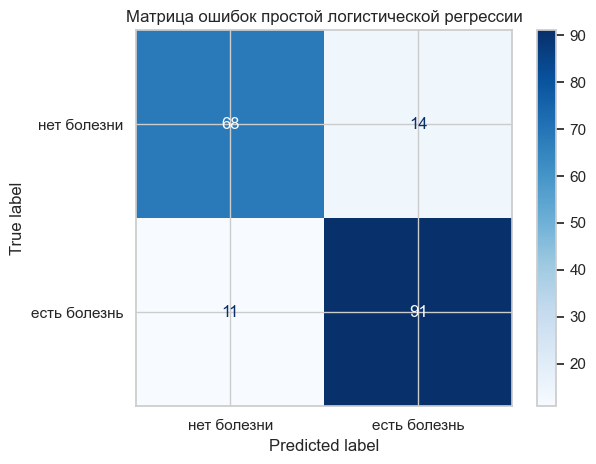

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["нет болезни", "есть болезнь"]))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["нет болезни", "есть болезнь"],
    cmap="Blues",
)
plt.title("Матрица ошибок простой логистической регрессии")
plt.tight_layout()
plt.show()

## 7. Аугментация

Для меньшего класса делаю дополнительные записи: сэмплирую с возвращением и добавляю небольшой шум к числовым признакам (~3% от std). Категориальные не трогаю, значения обрезаю по 1–99 перцентилям.

In [12]:
def make_statistical_augmentation(data, target_col, numeric_cols, categorical_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    base = data[numeric_cols + categorical_cols + [target_col]].copy()

    for col in numeric_cols:
        base[col] = base[col].fillna(base[col].median())
    for col in categorical_cols:
        base[col] = base[col].fillna(base[col].mode(dropna=True).iloc[0])

    counts = base[target_col].value_counts()
    majority_size = counts.max()
    augmented_parts = []

    for cls, count in counts.items():
        need = int(majority_size - count)
        if need <= 0:
            continue

        cls_rows = base[base[target_col] == cls]
        sampled = cls_rows.sample(n=need, replace=True, random_state=random_state).copy()

        for col in numeric_cols:
            std = cls_rows[col].std()
            noise_scale = 0.03 * std if pd.notna(std) and std > 0 else 0
            sampled[col] = sampled[col] + rng.normal(0, noise_scale, size=need)

            low, high = base[col].quantile([0.01, 0.99])
            sampled[col] = sampled[col].clip(low, high)

        sampled["is_augmented"] = 1
        augmented_parts.append(sampled)

    original = base.copy()
    original["is_augmented"] = 0

    if augmented_parts:
        return pd.concat([original] + augmented_parts, ignore_index=True)
    return original


augmented = make_statistical_augmentation(
    df,
    target_col="target",
    numeric_cols=numeric_features,
    categorical_cols=categorical_features,
    random_state=42,
)

augmented_path = Path("heart_disease_augmented.csv")
augmented.to_csv(augmented_path, index=False)

display(pd.crosstab(augmented["target"], augmented["is_augmented"], margins=True))
print(f"Сохранено: {augmented_path}")

is_augmented,0,1,All
target,,,
0,410,98,508
1,508,0,508
All,918,98,1016


Сохранено: heart_disease_augmented.csv


## 8. Визуализация

Несколько графиков по признакам, потом PCA и t-SNE для понижения размерности.

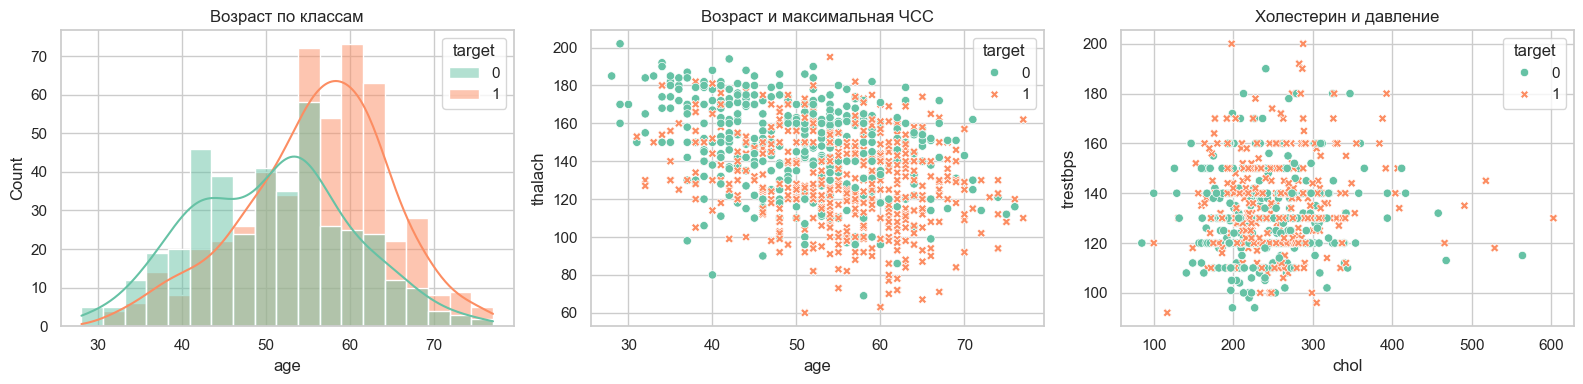

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=df, x="age", hue="target", kde=True, ax=axes[0])
axes[0].set_title("Возраст по классам")

sns.scatterplot(data=df, x="age", y="thalach", hue="target", style="target", ax=axes[1])
axes[1].set_title("Возраст и максимальная ЧСС")

sns.scatterplot(data=df, x="chol", y="trestbps", hue="target", style="target", ax=axes[2])
axes[2].set_title("Холестерин и давление")

for ax in axes:
    ax.set_xlabel(ax.get_xlabel())
    ax.set_ylabel(ax.get_ylabel())

plt.tight_layout()
plt.show()

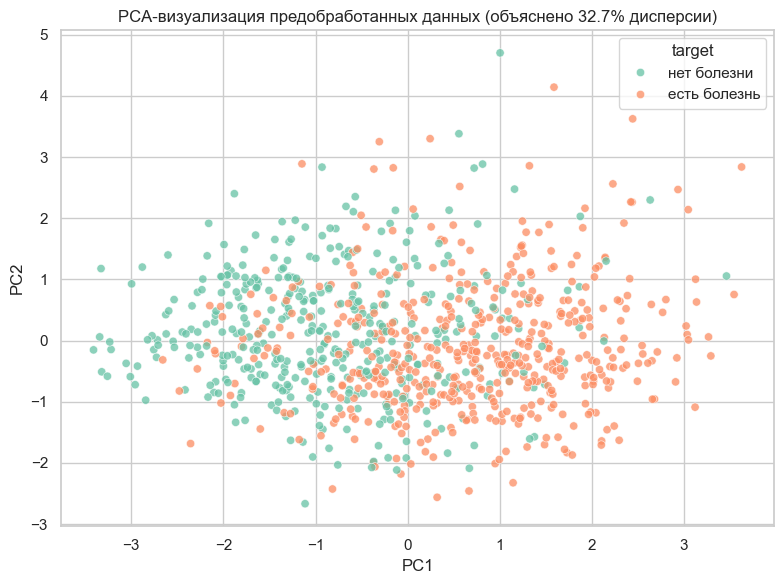

In [14]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_prepared)
pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
pca_df["target"] = y.map({0: "нет болезни", 1: "есть болезнь"}).to_numpy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target", alpha=0.75)
plt.title(
    "PCA-визуализация предобработанных данных "
    f"(объяснено {pca.explained_variance_ratio_.sum() * 100:.1f}% дисперсии)"
)
plt.tight_layout()
plt.show()

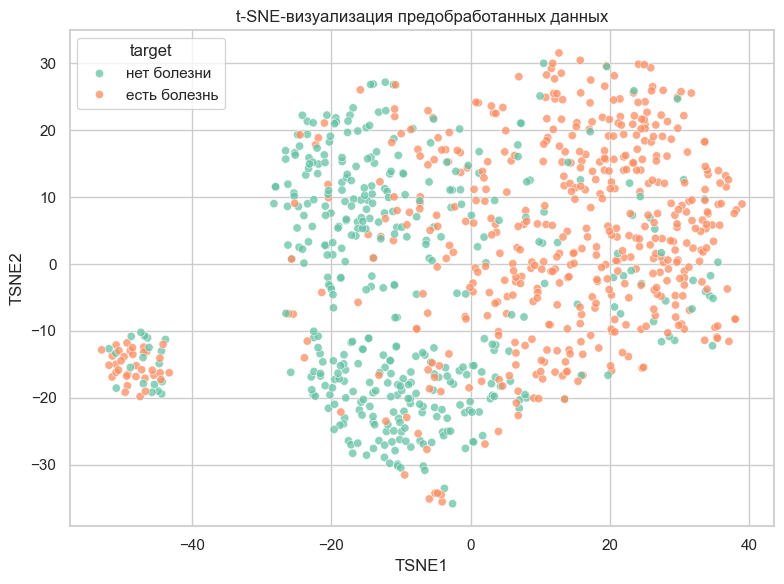

In [15]:
# сначала PCA до 30 компонент — ускоряет t-SNE
pca_for_tsne = PCA(n_components=min(30, X_prepared.shape[1]), random_state=42)
tsne_input = pca_for_tsne.fit_transform(X_prepared)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=42,
)
tsne_coords = tsne.fit_transform(tsne_input)

tsne_df = pd.DataFrame(tsne_coords, columns=["TSNE1", "TSNE2"])
tsne_df["target"] = y.map({0: "нет болезни", 1: "есть болезнь"}).to_numpy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="target", alpha=0.75)
plt.title("t-SNE-визуализация предобработанных данных")
plt.tight_layout()
plt.show()

## 9. Итоги

Выполнил предобработку датасета UCI Heart Disease:
- объединил 4 источника
- обработал явные и скрытые пропуски
- удалил `ca` (60%+ пропусков), остальное заполнил медианой/модой
- стандартизировал числовые, one-hot для категориальных
- сделал аугментацию для балансировки классов
- визуализировал через PCA и t-SNE

Результат: `heart_disease_preprocessed.csv` и `heart_disease_augmented.csv`